In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms, io
from PIL import Image

In [2]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

In [3]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [4]:
model.fc = nn.Linear(model.fc.in_features, 3)

In [6]:
model.load_state_dict(torch.load("flower_model_2.pth"))

<All keys matched successfully>

In [7]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
device

device(type='cuda')

In [12]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [13]:
def predict(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        top_prob, top_class = probs.max(dim=1)

    return class_names[top_class.item()], top_prob.item()

In [ ]:
class_names = ["daisy", "rose", "sunflower"]

In [17]:
label, confidence = predict("test1.jpg", model, class_names)

In [18]:
print(f"预测: {label} (置信度: {confidence:.2%})")

预测: daisy (置信度: 99.75%)


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [20]:
def evaluate(model, dataloader, class_names):
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)

            preds = outputs.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    print("混淆矩阵: ")
    print(cm)

In [22]:
from torch.utils.data import DataLoader
from torchvision import datasets

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

In [23]:
evaluate(model, val_loader, class_names)

              precision    recall  f1-score   support

       daisy       1.00      1.00      1.00        20
        rose       1.00      1.00      1.00        20
   sunflower       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

混淆矩阵: 
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


In [24]:
import matplotlib.pyplot as plt

In [25]:
plt.rcParams["font.family"] = ["DejaVu Sans", "SimHei", "Microsoft YaHei"]
plt.rcParams['axes.unicode_minus'] = False

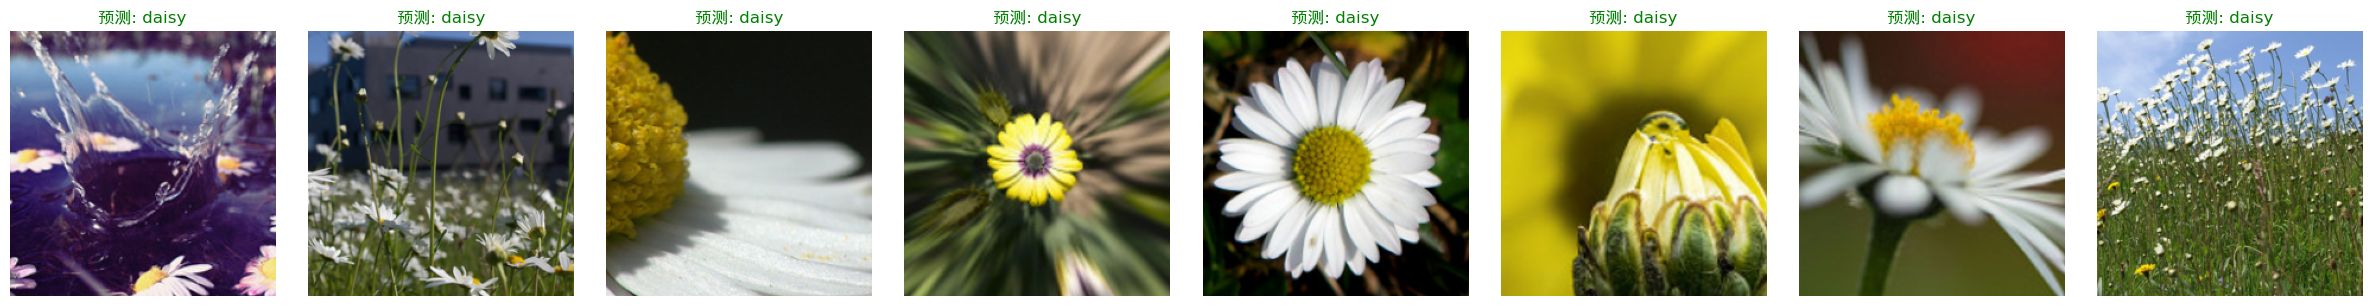

In [32]:
def show_predictions(model, dataloader, class_names, n=8):
    model.eval()

    images, labels = next(iter(dataloader))
    images_gpu = images[:n].to(device)

    with torch.no_grad():
        preds = model(images_gpu).argmax(dim=1).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    for i, ax in enumerate(axes):
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()

        ax.imshow(img)
        color = "green" if preds[i] == labels[i] else "red"
        ax.set_title(f"预测: {class_names[preds[i]]}", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=100)
    plt.show()

show_predictions(model, val_loader, class_names)

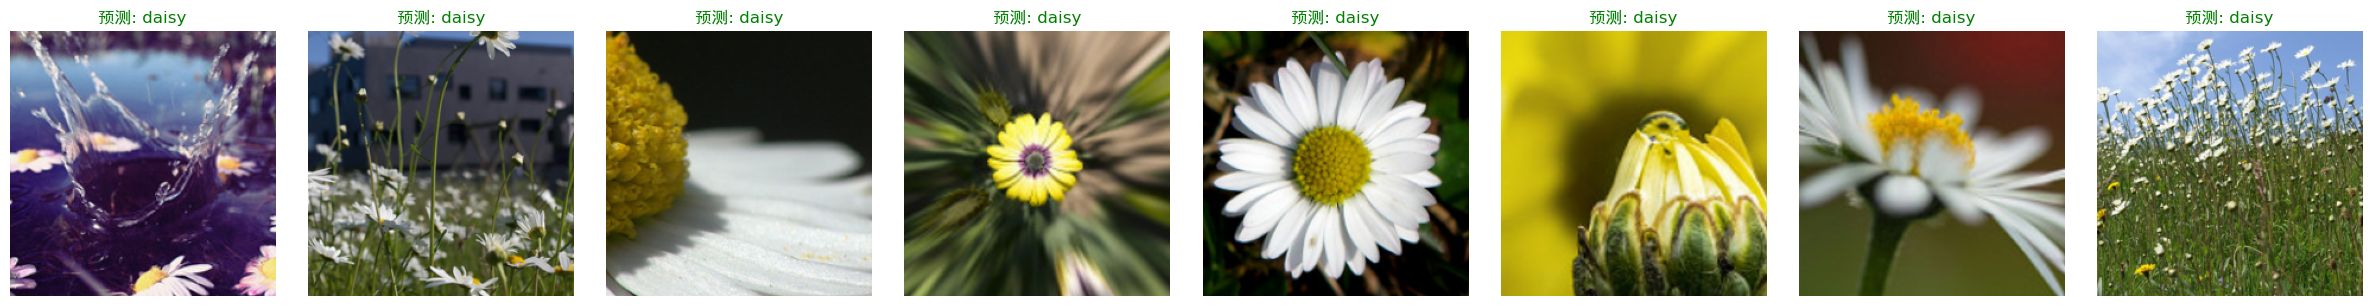

In [34]:
import random


def show_predictions(model, dataloader, class_names, n=8):
    model.eval()

    data_list = list(iter(dataloader))
    images, labels = random.choice(data_list)
    images_gpu = images[:n].to(device)

    with torch.no_grad():
        preds = model(images_gpu).argmax(dim=1).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    for i, ax in enumerate(axes):
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()

        ax.imshow(img)
        color = "green" if preds[i] == labels[i] else "red"
        ax.set_title(f"预测: {class_names[preds[i]]}", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=100)
    plt.show()

show_predictions(model, val_loader, class_names)

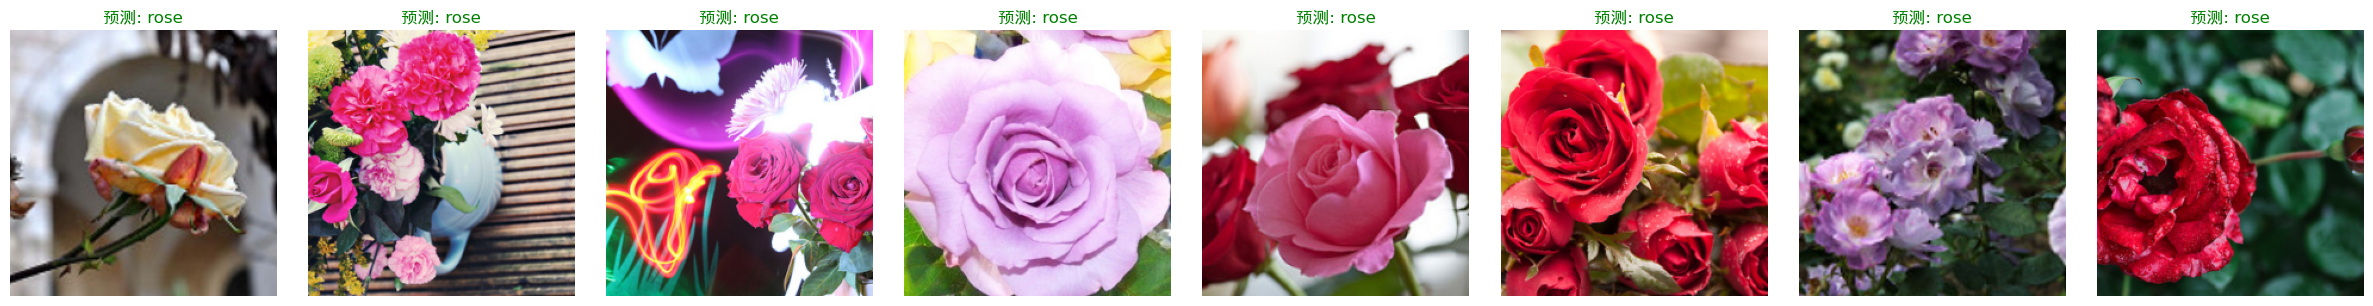

In [37]:
def show_predictions_random(model, dataloader, class_names, n=8):
    model.eval()
    all_imgs = []
    all_labels = []
    # 遍历少量数据做采样，避免加载整个数据集
    for imgs, labs in dataloader:
        all_imgs.append(imgs)
        all_labels.append(labs)
        if len(all_imgs) * imgs.shape[0] > n * 3:
            break
    # 拼接所有图片
    total_imgs = torch.cat(all_imgs)
    total_labels = torch.cat(all_labels)
    # 随机索引
    idx = torch.randperm(len(total_imgs))[:n]
    images = total_imgs[idx]
    labels = total_labels[idx]

    images_gpu = images.to(device)
    with torch.no_grad():
        preds = model(images_gpu).argmax(dim=1).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    for i, ax in enumerate(axes):
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        color = "green" if preds[i] == labels[i] else "red"
        ax.set_title(f"GT:{class_names[labels[i]]}\nPred:{class_names[preds[i]]}", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, val_loader, class_names)